<a href="https://colab.research.google.com/github/sevcenkolera/sevcenko/blob/main/Shevchenko_lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування красивого стилю для всіх графіків
sns.set_theme(style="whitegrid", context="talk")

# 1. Загрузити датасет
df = pd.read_csv("Museum_Visitors (2).csv")

# 2. Вивести перші 5 рядків датасету
display(df.head())

,Month,America Tropical Interpretive Center,Avila Adobe,Chinese American Museum,Gateway to Nature Center,Firehouse Museum,Hellman Quon,IAMLA,Pico House,Visitor Center/ El Tranquilo Gallery,Museum of Social Justice,Biscailuz Gallery/ PK Outdoor Exhibit
0,01/01/2014 12:00:00 AM,6602,24778,1581,NaN,4486,0.0,NaN,2204.0,2961.0,NaN,NaN
1,02/01/2014 12:00:00 AM,5029,18976,1785,NaN,4172,0.0,NaN,1330.0,2276.0,NaN,NaN
2,03/01/2014 12:00:00 AM,8129,25231,3229,NaN,7082,70.0,NaN,4320.0,3116.0,NaN,NaN
3,04/01/2014 12:00:00 AM,2824,26989,2129,NaN,6756,250.0,NaN,3277.0,2808.0,NaN,NaN
4,05/01/2014 12:00:00 AM,10694,36883,3676,NaN,10858,135.0,NaN,4122.0,3987.0,NaN,NaN


In [ ]:
# 3. Провести попередній аналіз даних
print("=== Розмір датасету ===")
print(f"Рядків: {df.shape[0]}, Стовпців: {df.shape[1]}\n")

print("=== Типи даних ===")
print(df.dtypes, "\n")

print("=== Кількість пропусків у кожному стовпці ===")
print(df.isnull().sum(), "\n")

# 4. Перевірити наявність дублікатів
duplicates_count = df.duplicated().sum()
print(f"=== Знайдено дублікатів: {duplicates_count} ===")

if duplicates_count > 0:
    df = df.drop_duplicates()
    print(f"Розмір таблиці після видалення дублікатів: {df.shape}")

=== Розмір датасету ===
Рядків: 85, Стовпців: 12

=== Типи даних ===
Month                                     object
America Tropical Interpretive Center       int64
Avila Adobe                                int64
Chinese American Museum                    int64
Gateway to Nature Center                 float64
Firehouse Museum                           int64
Hellman Quon                             float64
IAMLA                                    float64
Pico House                               float64
Visitor Center/ El Tranquilo Gallery     float64
Museum of Social Justice                 float64
Biscailuz Gallery/ PK Outdoor Exhibit    float64
dtype: object 

=== Кількість пропусків у кожному стовпці ===
Month                                     0
America Tropical Interpretive Center      0
Avila Adobe                               0
Chinese American Museum                   0
Gateway to Nature Center                 53
Firehouse Museum                          0
Hellman Quon     

In [ ]:
# 5. Змінити назви стовпців (великі букви на маленькі, пробіли на підкреслення, Month на date)
df.rename(columns={'Month': 'date'}, inplace=True)
df.columns = [col.strip().lower().replace(' ', '_').replace('/', '_') for col in df.columns]

print("Нові назви стовпців:")
print(df.columns.tolist())

# Перетворення стовпця 'date' у формат datetime для роботи з датами
df['date'] = pd.to_datetime(df['date'])

# 6. Про які роки містить інформацію датасет
years = df['date'].dt.year.unique()
print(f"\nДатасет містить інформацію про такі роки: {sorted(years)}")

Нові назви стовпців:
['date', 'america_tropical_interpretive_center', 'avila_adobe', 'chinese_american_museum', 'gateway_to_nature_center', 'firehouse_museum', 'hellman_quon', 'iamla', 'pico_house', 'visitor_center__el_tranquilo_gallery', 'museum_of_social_justice', 'biscailuz_gallery__pk_outdoor_exhibit']

Датасет містить інформацію про такі роки: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)]


/tmp/ipykernel_303/3154892614.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'])


In [ ]:
# 7. Обчислити середню кількість відвідувачів для кожного музею протягом всього періоду
print("=== Середня кількість відвідувачів для кожного музею ===")
mean_visitors = df.drop('date', axis=1).mean().round(2)
print(mean_visitors)

# 8. Знайти мінімальну та максимальну кількість відвідувачів для кожного музею за 2018 рік
print("\n=== Мінімальна та максимальна кількість відвідувачів за 2018 рік ===")
df_2018 = df[df['date'].dt.year == 2018].drop('date', axis=1)
print("Мінімально:\n", df_2018.min().dropna())
print("\nМаксимально:\n", df_2018.max().dropna())

# 9. Визначити місяці з найвищою і найнижчою загальною кількістю відвідувачів серед усіх музеїв для 2015 року
df_2015 = df[df['date'].dt.year == 2015].copy()
df_2015['total_visitors'] = df_2015.drop('date', axis=1).sum(axis=1)

max_month = df_2015.loc[df_2015['total_visitors'].idxmax()]['date'].month_name()
min_month = df_2015.loc[df_2015['total_visitors'].idxmin()]['date'].month_name()

print(f"\n=== Місяці 2015 року за загальною відвідуваністю ===")
print(f"Найвища відвідуваність: {max_month}")
print(f"Найнижча відвідуваність: {min_month}")

# 10. Порівняти кількість відвідувачів музею "Avila Adobe" у літні і зимові місяці 2018 року
df_2018_full = df[df['date'].dt.year == 2018].copy()
df_2018_full['month_num'] = df_2018_full['date'].dt.month

summer_visitors = df_2018_full[df_2018_full['month_num'].isin([6, 7, 8])]['avila_adobe'].sum()
winter_visitors = df_2018_full[df_2018_full['month_num'].isin([12, 1, 2])]['avila_adobe'].sum()

print(f"\n=== Відвідуваність Avila Adobe у 2018 році ===")
print(f"Влітку: {summer_visitors} осіб")
print(f"Взимку: {winter_visitors} осіб")

# 11. Знайти кореляцію між кількістю відвідувачів в кожному з музеїв та датами у 2016 році
print("\n=== Кореляція між кількістю відвідувачів та перебігом часу (місяцями) у 2016 році ===")
df_2016 = df[df['date'].dt.year == 2016].copy()
# Щоб знайти кореляцію з "датами", переведемо дату у порядковий номер місяця
df_2016['month_num'] = df_2016['date'].dt.month
correlation_2016 = df_2016.drop('date', axis=1).corr()['month_num'].drop('month_num').round(3)
print(correlation_2016.dropna())

=== Середня кількість відвідувачів для кожного музею ===
america_tropical_interpretive_center      5637.69
avila_adobe                              19904.95
chinese_american_museum                   2359.12
gateway_to_nature_center                  1247.38
firehouse_museum                          5286.78
hellman_quon                               353.46
iamla                                      882.61
pico_house                                1329.71
visitor_center__el_tranquilo_gallery      2634.80
museum_of_social_justice                  2125.97
biscailuz_gallery__pk_outdoor_exhibit     1088.62
dtype: float64

=== Мінімальна та максимальна кількість відвідувачів за 2018 рік ===
Мінімально:
 america_tropical_interpretive_center      3180.0
avila_adobe                              14718.0
chinese_american_museum                   2078.0
firehouse_museum                          3306.0
iamla                                      965.0
pico_house                                 185.0
m

/tmp/ipykernel_303/382175986.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year', y='chinese_american_museum', palette='viridis')
/tmp/ipykernel_303/382175986.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mean_visitors_df, x='Average Visitors', y='Museum', palette='mako')


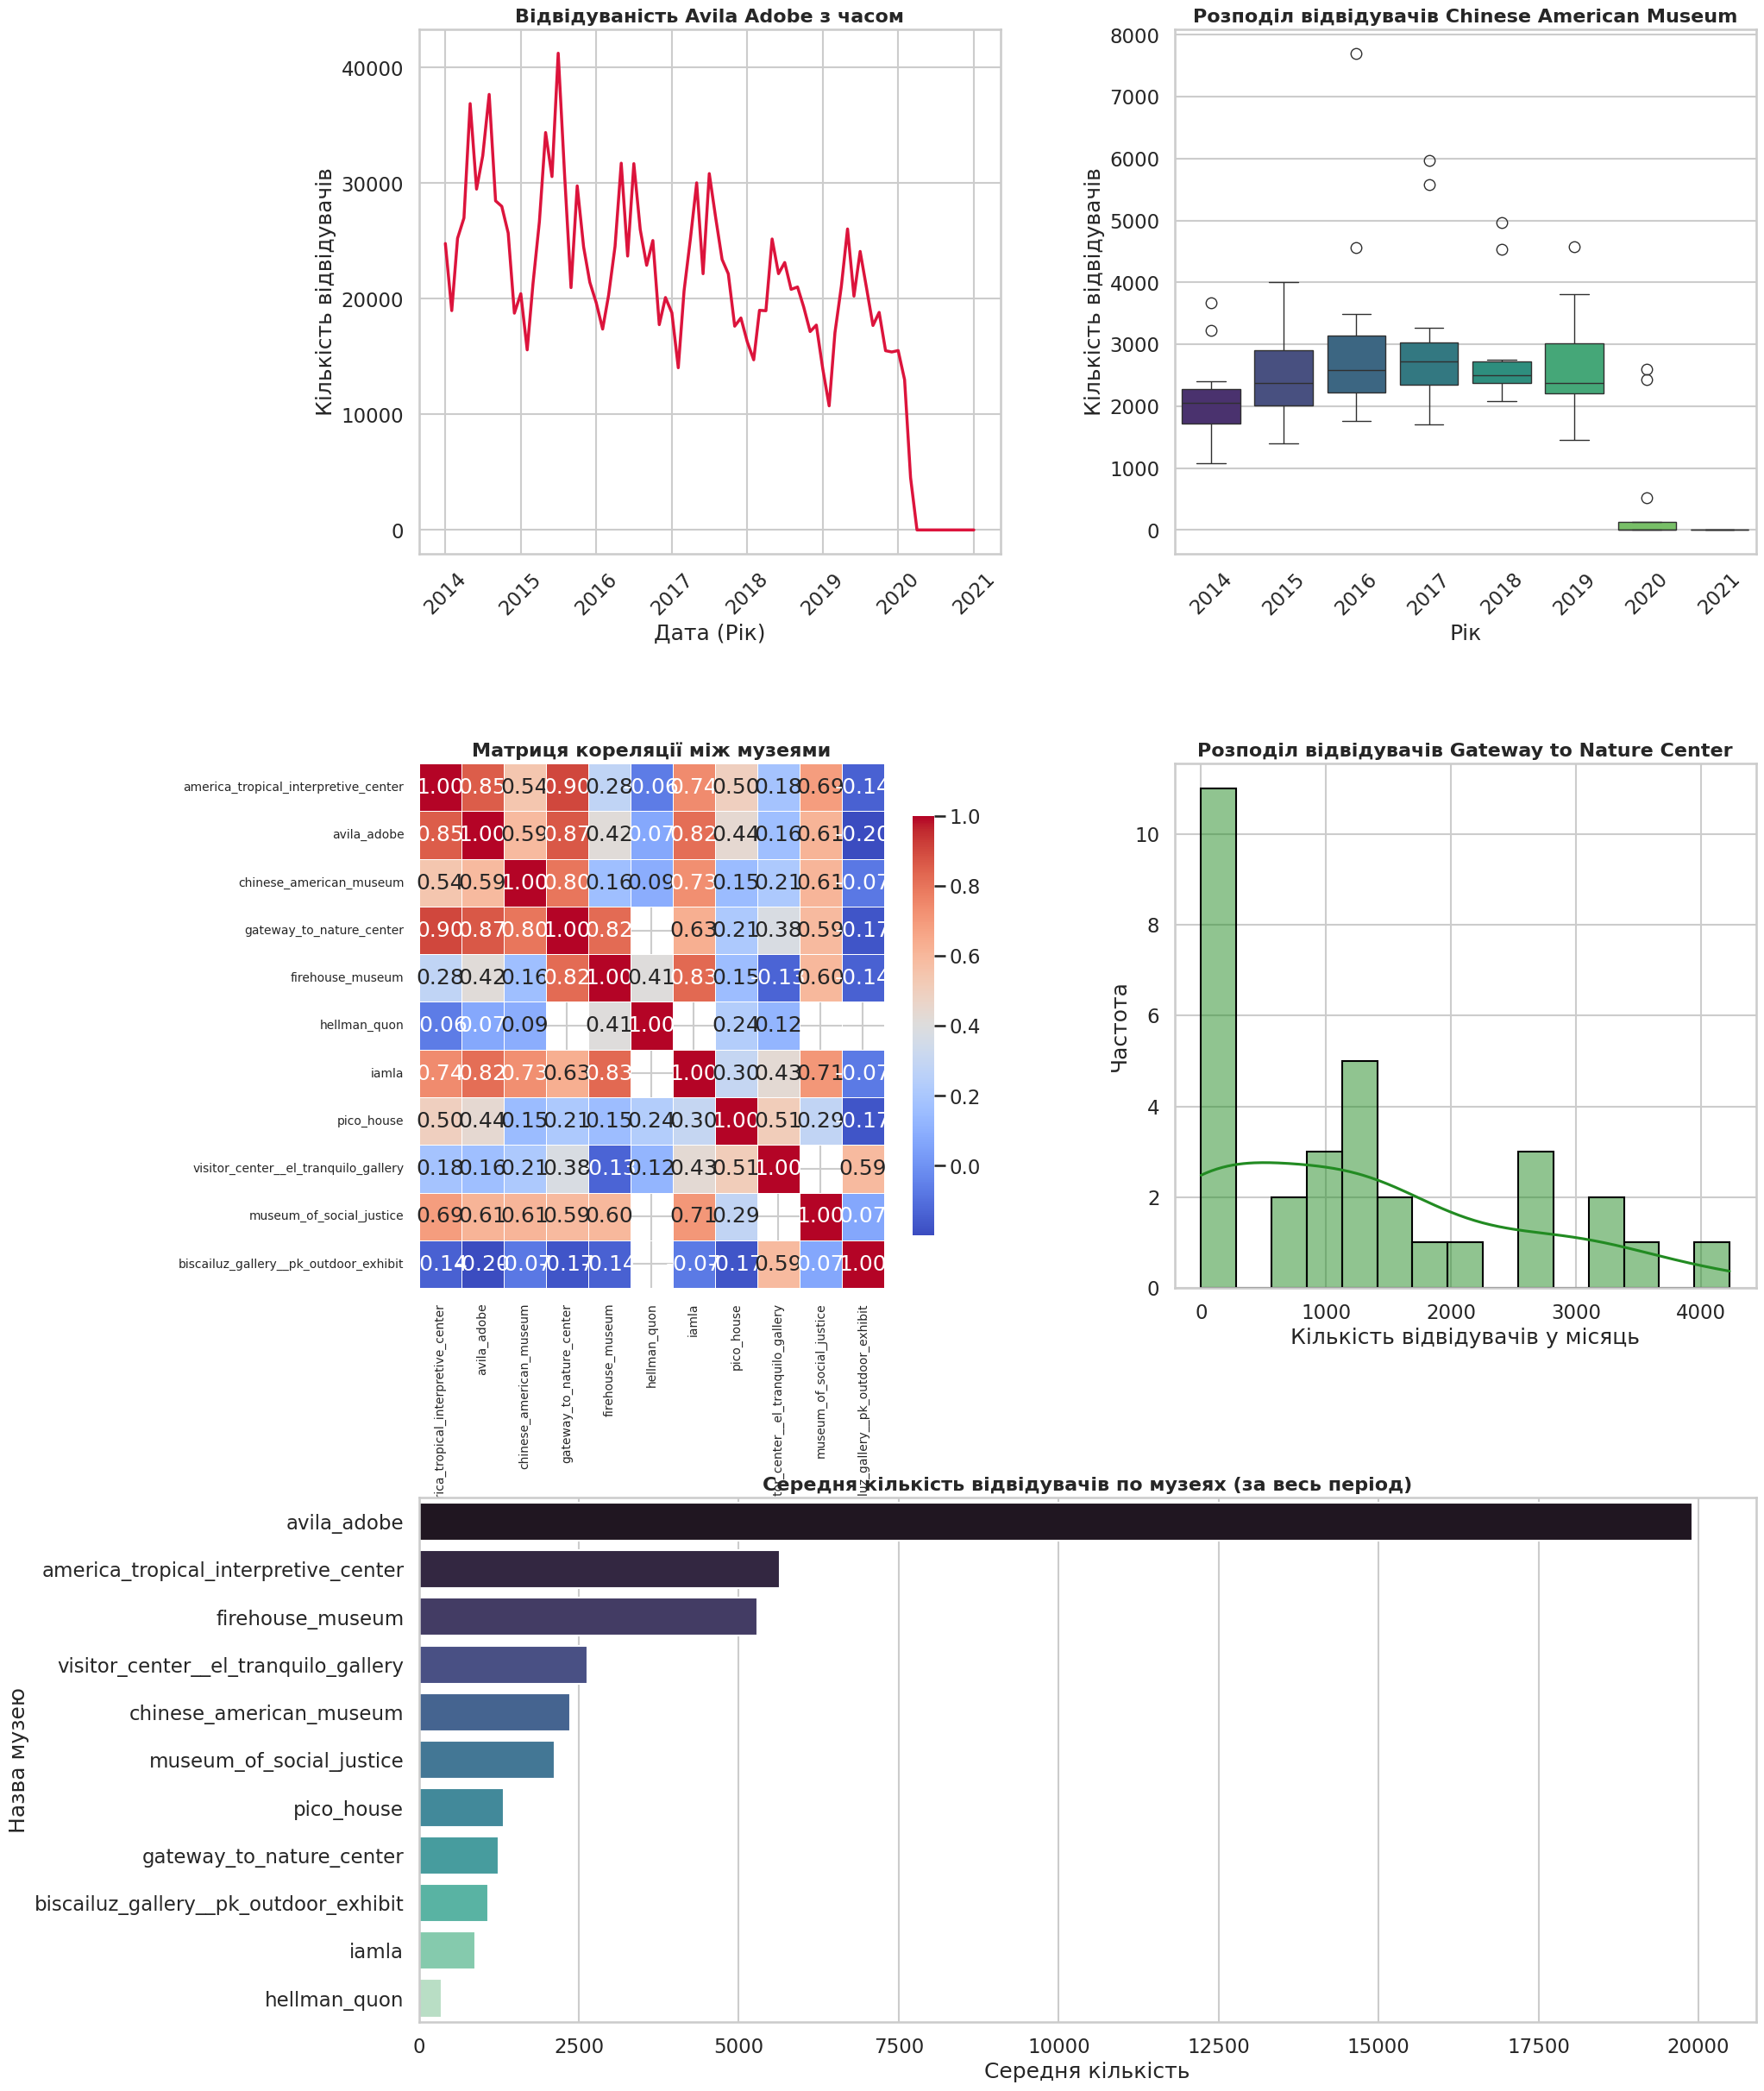

In [ ]:
plt.figure(figsize=(20, 30))
# Налаштуємо простір між графіками
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# 1. Лінійний графік (відвідуваність Avila Adobe з часом)
plt.subplot(3, 2, 1)
sns.lineplot(data=df, x='date', y='avila_adobe', color='crimson', linewidth=2.5)
plt.title('Відвідуваність Avila Adobe з часом', fontsize=16, fontweight='bold')
plt.xlabel('Дата (Рік)')
plt.ylabel('Кількість відвідувачів')
plt.xticks(rotation=45)

# 2. Boxplot (розподіл відвідувачів Chinese American Museum по роках)
plt.subplot(3, 2, 2)
# Додамо колонку з роком для побудови боксплоту
df['year'] = df['date'].dt.year
sns.boxplot(data=df, x='year', y='chinese_american_museum', palette='viridis')
plt.title('Розподіл відвідувачів Chinese American Museum', fontsize=16, fontweight='bold')
plt.xlabel('Рік')
plt.ylabel('Кількість відвідувачів')
plt.xticks(rotation=45)

# 3. Heatmap (кореляція між усіма музеями)
plt.subplot(3, 2, 3)
museum_cols = [col for col in df.columns if col not in ['date', 'year']]
corr_matrix = df[museum_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Матриця кореляції між музеями', fontsize=16, fontweight='bold')
plt.xticks(rotation=90, fontsize=10)
plt.yticks(fontsize=10)

# 4. Histogram (розподіл кількості відвідувачів Gateway to Nature Center)
plt.subplot(3, 2, 4)
sns.histplot(df['gateway_to_nature_center'].dropna(), bins=15, kde=True, color='forestgreen', edgecolor='black')
plt.title('Розподіл відвідувачів Gateway to Nature Center', fontsize=16, fontweight='bold')
plt.xlabel('Кількість відвідувачів у місяць')
plt.ylabel('Частота')

# 5. Barplot (середня кількість відвідувачів по музеях за всі роки)
plt.subplot(3, 1, 3) # Займає всю ширину знизу
mean_visitors_df = mean_visitors.reset_index()
mean_visitors_df.columns = ['Museum', 'Average Visitors']
mean_visitors_df = mean_visitors_df.sort_values(by='Average Visitors', ascending=False)

sns.barplot(data=mean_visitors_df, x='Average Visitors', y='Museum', palette='mako')
plt.title('Середня кількість відвідувачів по музеях (за весь період)', fontsize=16, fontweight='bold')
plt.xlabel('Середня кількість')
plt.ylabel('Назва музею')

# Виведення всіх графіків на екран
plt.show()

ВИСНОВКИ
Якість даних: У датасеті присутні пропуски в даних (NaN) у новіших/менших музеях, що може свідчити про те, що ці музеї відкрилися пізніше або не вели облік в певні роки (наприклад, Gateway to Nature Center). Лідери відвідуваності: Найпопулярнішим музеєм з величезним відривом є Avila Adobe, а найменш популярним — Hellman Quon.Сезонність: Кількість відвідувачів сильно залежить від сезону. Наприклад, у музеї "Avila Adobe" влітку 2018 року було значно більше людей, ніж взимку, що свідчить про туристичні піки.Кореляція: Heatmap показав, що між певними музеями є сильна позитивна кореляція. Це означає, що коли зростає відвідуваність в одному музеї, вона паралельно зростає і в іншому (можливо, люди купують комплексні тури або музеї знаходяться дуже близько один до одного).